In [1]:
# imports and setup

import os
import base64
import sys
from dotenv import load_dotenv
from typing import Any, Dict, List, Optional, Tuple
from PIL import Image   # noqa: F401
from pydantic import BaseModel as PydanticBaseModel
from pydantic import Field
from pydantic_settings import BaseSettings
import oracledb
import io
import cv2
import fitz
import numpy as np
import boto3
from botocore.config import Config
import json
import re
import time
from tqdm import tqdm
import mariadb
import pandas as pd
from collections import defaultdict

#dont limit the visualization of all the colluns of a pandas dataframe
pd.set_option("display.max_columns", None)

# Add project root to Python path so we can import from app module
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.append(project_root)
# Now we can import from app (after adding to sys.path)
from app.utils.logger import get_logger
# Load environment variables from the project root directory
env_path = os.path.join(project_root, '.env')
load_dotenv(env_path)

logger = get_logger(name=__name__)

In [2]:

class AppConstants:
    """Constantes globais para a aplicação."""

    BEDROCK_DEFAULT_MODEL_ID = "anthropic.claude-3-7-sonnet-20240729-v1:0"
    # DEFAULT_PROMPT_EXTRACAO_PATH = "prompt_extracao_laudo.txt"
    # DEFAULT_PROMPT_RESUMO_PATH = "prompt_resumo.txt"
    # S3_BUCKET_NAME = "agente-ai-laudos"
    # S3_RESULTS_PREFIX = "resultados"
    # S3_DEBUG_PREFIX = "debug"
    MAX_RETRIES = 5
    INITIAL_BACKOFF_SECONDS = 2


In [3]:
class Settings(BaseSettings):
    """Carrega e valida as configurações a partir de variáveis de ambiente."""

    ORACLE_USER: str
    ORACLE_PASSWORD: str
    ORACLE_DSN: str
    ORACLE_INSTANT_CLIENT_PATH: Optional[str] = Field(
        None, alias="oracle_instant_client_path"
    )
    AWS_ACCESS_KEY_ID: str
    AWS_SECRET_ACCESS_KEY: str
    AWS_BEDROCK_REGION: str
    BEDROCK_MODEL_ID: str = AppConstants.BEDROCK_DEFAULT_MODEL_ID
    MARIADB_USER: str
    MARIADB_PASSWORD: str
    MARIADB_HOST: str
    MARIADB_PORT: int = 3306
    MARIADB_DATABASE: str
    API_BASE_URL: Optional[str] = Field(None, alias="api_base_url")
    API_USERNAME: Optional[str] = Field(None, alias="username")
    API_PASSWORD: Optional[str] = Field(None, alias="password")

    class Config:
        env_file = ".env"
        env_file_encoding = "utf-8"


In [4]:
def criar_boto3_client(
    service_name: str, settings: Settings, config: Optional[Config] = None
) -> boto3.client:
    try:
        logger.info(
            f"Criando cliente {service_name.upper()} para a região: {settings.AWS_BEDROCK_REGION}..."
        )
        client = boto3.client(
            service_name,
            region_name=settings.AWS_BEDROCK_REGION,
            aws_access_key_id=settings.AWS_ACCESS_KEY_ID,
            aws_secret_access_key=settings.AWS_SECRET_ACCESS_KEY,
            config=config,
        )
        logger.info(f"Cliente {service_name.upper()} criado com sucesso.")
        return client
    except Exception as e:
        logger.critical(f"Não foi possível criar o cliente {service_name.upper()}: {e}")
        raise


In [5]:
def load_query_from_file(file_path: str) -> str:
    """
    Load SQL query from a text file
    
    Args:
        file_path: Path to the query file
    
    Returns:
        Query string
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
            
        # Extract just the query part (remove variable assignment)
        if '"""' in content:
            # Find the query between triple quotes
            start = content.find('"""') + 3
            end = content.rfind('"""')
            query = content[start:end].strip()
        else:
            # If no triple quotes, assume entire file is the query
            query = content.strip()
            
        return query
        
    except Exception as e:
        logger.error(f"❌ Error loading query from file: {e}")
        return None

In [6]:
# connection to the database oracle

class OracleService:
    def __init__(self, settings: Settings):
        self.config = {
            "user": settings.ORACLE_USER,
            "password": settings.ORACLE_PASSWORD,
            "dsn": settings.ORACLE_DSN,
        }
        self.connection = None
        if settings.ORACLE_INSTANT_CLIENT_PATH and os.path.isdir(
            settings.ORACLE_INSTANT_CLIENT_PATH
        ):
            logger.info(
                f"Inicializando Oracle Client de: {settings.ORACLE_INSTANT_CLIENT_PATH}"
            )
            oracledb.init_oracle_client(lib_dir=settings.ORACLE_INSTANT_CLIENT_PATH)

    def __enter__(self):
        """Establishes the database connection when entering the 'with' block."""
        try:
            self.connection = oracledb.connect(**self.config)
            logger.info(f"✅ Connection established to {self.config['dsn']}")
            return self
        except Exception as e:
            logger.error(f"❌ Error connecting to Oracle: {e}")
            raise

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Closes the database connection when exiting the 'with' block."""
        if self.connection:
            try:
                self.connection.close()
                logger.info("✅ Oracle connection closed.")
            except Exception as e:
                logger.error(f"❌ Error closing Oracle connection: {e}")
        # If an exception occurred within the 'with' block, it will be re-raised.

    def execute_query(self, query: str, fetch_limit: int = None) -> Optional[List[Dict[str, Any]]]:
        """
        Execute a query using the existing Oracle connection.
        
        Args:
            query: SQL query to execute
            fetch_limit: Maximum number of rows to fetch (None for all)
        
        Returns:
            List of dictionaries containing query results, or None if error
        """
        if not self.connection:
            logger.error("❌ Cannot execute query: Not connected. Use within a 'with' block.")
            return None
            
        try:
            with self.connection.cursor() as cursor:
                logger.info("Executing query...")
                cursor.execute(query)
                
                columns = [desc[0] for desc in cursor.description]
                
                if fetch_limit:
                    rows = cursor.fetchmany(fetch_limit)
                else:
                    rows = cursor.fetchall()
                
                results = []
                for row in rows:
                    row_dict = {}
                    for i, col_val in enumerate(row):
                        col_name = columns[i]
                        if isinstance(col_val, oracledb.LOB):
                            row_dict[col_name] = col_val.read()
                        else:
                            row_dict[col_name] = col_val
                    results.append(row_dict)
                
                logger.info(f"✅ Fetched {len(results)} rows.")
                return results
                    
        except Exception as e:
            logger.error(f"Error executing query: {e}")
            return None

In [7]:
class MariaDBService:
    """Context manager for MariaDB database connections."""
    
    def __init__(self, settings: Settings):
        self.config = {
            "user": settings.MARIADB_USER,
            "password": settings.MARIADB_PASSWORD,
            "host": settings.MARIADB_HOST,
            "port": settings.MARIADB_PORT,
            "database": settings.MARIADB_DATABASE,
        }
        self.connection = None

    def __enter__(self):
        """Establishes the database connection when entering the 'with' block."""
        try:
            self.connection = mariadb.connect(**self.config)
            logger.info(f"✅ MariaDB connection established to {self.config['host']}:{self.config['port']}/{self.config['database']}")
            return self
        except mariadb.Error as e:
            logger.error(f"❌ Error connecting to MariaDB: {e}")
            raise

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Closes the database connection when exiting the 'with' block."""
        if self.connection:
            try:
                self.connection.close()
                logger.info("✅ MariaDB connection closed.")
            except mariadb.Error as e:
                logger.error(f"❌ Error closing MariaDB connection: {e}")
        # If an exception occurred within the 'with' block, it will be re-raised.

    def execute_query(self, query: str, fetch_limit: int = None) -> Optional[List[Dict[str, Any]]]:
        """
        Execute a query using the existing MariaDB connection.
        
        Args:
            query: SQL query to execute
            fetch_limit: Maximum number of rows to fetch (None for all)
        
        Returns:
            List of dictionaries containing query results, or None if error
        """
        if not self.connection:
            logger.error("❌ Cannot execute query: Not connected. Use within a 'with' block.")
            return None
            
        try:
            with self.connection.cursor(dictionary=True) as cursor:
                logger.info("Executing MariaDB query...")
                cursor.execute(query)
                
                if fetch_limit:
                    results = cursor.fetchmany(fetch_limit)
                else:
                    results = cursor.fetchall()
                
                logger.info(f"✅ Fetched {len(results)} rows from MariaDB.")
                return results
                    
        except mariadb.Error as e:
            logger.error(f"Error executing MariaDB query: {e}")
            return None

    

In [8]:
# aviso cirurgia query file
aviso_cirurgia_query_file = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/query_aviso_cirurgia.txt"
if os.path.exists(aviso_cirurgia_query_file):
    aviso_cirurgia_query = load_query_from_file(aviso_cirurgia_query_file)
    if aviso_cirurgia_query:
        logger.info("✅ Aviso cirurgia query loaded successfully from file!")
    else:
        logger.error("❌ Failed to load aviso cirurgia query from file")
else:
    logger.error(f"❌ Aviso cirurgia query file not found: {aviso_cirurgia_query_file}")

{"timestamp": "2025-08-11T09:51:00", "level": "INFO", "name": "__main__", "message": "✅ Aviso cirurgia query loaded successfully from file!", "filename": "3187017494.py", "lineno": 6}


In [9]:
# avisos query using maria db context manager
logger.info("🚀 Testing avisos query with MariaDB context manager...")
logger.info("=" * 50)
try:
    settings = Settings()
    
    # Use the service as a context manager
    with MariaDBService(settings) as maria_service:
        maria_results = maria_service.execute_query(aviso_cirurgia_query, fetch_limit=500)
        if maria_results:
            logger.info(f"\n✅ Avisos query executed successfully! Found {len(maria_results)} sample records")
            logger.info("\n📋 Sample Results:")
            logger.info("-" * 50)
            
            for i, record in enumerate(maria_results, 1):
                logger.info(f"\nRecord {i}:")
                for key, value in record.items():
                    logger.info(f"  {key}: {value}")
                    
            logger.info(f"\n📊 To get all records, run the query without fetch_limit.")
            
        else:
            logger.error("❌ No results returned or query failed inside 'with' block")
except Exception as e:
    logger.error(f"❌ An error occurred while executing avisos query: {e}")

# If results were fetched, convert to DataFrame
if maria_results:
    df_avisos_maria = pd.DataFrame(maria_results)
    # rename the surgical_order_id column to match the Oracle column
    df_avisos_maria.rename(columns={"surgical_order_id": "CD_AVISO_CIRURGIA"}, inplace=True)
    logger.info("✅ Avisos DataFrame created successfully.")
    logger.debug(f"DataFrame content:\n{df_avisos_maria}")
else:
    logger.error("❌ No results to create DataFrame from avisos query.")
# Display the DataFrame info and head
logger.info(df_avisos_maria.info())
df_avisos_maria.head()

{"timestamp": "2025-08-11T09:51:05", "level": "INFO", "name": "__main__", "message": "🚀 Testing avisos query with MariaDB context manager...", "filename": "2007119028.py", "lineno": 2}
{"timestamp": "2025-08-11T09:51:05", "level": "INFO", "name": "__main__", "message": "==================================================", "filename": "2007119028.py", "lineno": 3}
{"timestamp": "2025-08-11T09:51:05", "level": "INFO", "name": "__main__", "message": "==================================================", "filename": "2007119028.py", "lineno": 3}
{"timestamp": "2025-08-11T09:51:06", "level": "INFO", "name": "__main__", "message": "✅ MariaDB connection established to srvawsdb002.cow7tj30bxpl.us-east-1.rds.amazonaws.com:3306/", "filename": "2645936225.py", "lineno": 18}
{"timestamp": "2025-08-11T09:51:06", "level": "INFO", "name": "__main__", "message": "Executing MariaDB query...", "filename": "2645936225.py", "lineno": 51}
{"timestamp": "2025-08-11T09:51:06", "level": "INFO", "name": "__main

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CD_AVISO_CIRURGIA      500 non-null    int64         
 1   hospital_id            500 non-null    int64         
 2   hospitalization_type   500 non-null    object        
 3   patient_hospitalized   500 non-null    object        
 4   friendly_name          500 non-null    object        
 5   filter_name_hospital   500 non-null    object        
 6   doctor_name            500 non-null    object        
 7   specialty              500 non-null    object        
 8   patient_name           500 non-null    object        
 9   with_opme              500 non-null    object        
 10  opme                   300 non-null    object        
 11  procedimento_teste     500 non-null    object        
 12  created_at             500 non-null    datetime64[ns]
 13  expec

,CD_AVISO_CIRURGIA,hospital_id,hospitalization_type,patient_hospitalized,friendly_name,filter_name_hospital,doctor_name,specialty,patient_name,with_opme,opme,procedimento_teste,created_at,expected_date,status,provider,dt_status,dt_status_format,mes_ano_criacao,health_insurance_code,health_insurance_name,cluster_hub
0,791978,1,elective,Não,Sto Agostinho,Sto Agostinho,THAIS SYRIO AMARAL,GINECOLOGIA E OBSTETRICIA,ANA CAROLINA BELEM RIOS,Com OPME,"{""solicitations"":[{""description"":""ALÇA DE RESS...",HISTEROSCOPIA COM RESSECTOSCÓPIO PARA MIOMECTO...,2025-01-01 15:13:37,2025-01-02 06:00:00,Realizada,None,2025-03-20 18:14:41,2025-03-20,2025-01-01,302,COPASS,CLUSTER RMBH/SALVADOR
1,792045,1,elective,Não,Sto Agostinho,Sto Agostinho,ROGER LAGE ALVES,CIRURGIA GERAL,NILDA CRISTINA BRAGA RODRIGUES,Com OPME,"{""providers"":[""JOHNSON""],""solicitations"":[{""de...",COLECISTECTOMIA SEM COLANGIOGRAFIA POR V,2025-01-02 11:22:27,2025-01-20 03:00:00,Realizada,None,2025-01-27 18:42:04,2025-01-27,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
2,792058,1,elective,Não,Sto Agostinho,Sto Agostinho,RAFAEL BRANDAO BITENCOURT,CIRURGIA GERAL,GABRIELLY CELIANA DE REZENDE,Com OPME,"{""solicitations"":[{""description"":""TELA DE MARL...",HERNIORRAFIA RECIDIVANTE,2025-01-02 12:10:38,NaT,Realizada,None,2025-03-28 11:26:03,2025-03-28,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
3,792061,1,elective,Não,Sto Agostinho,Sto Agostinho,PRISCILA FREITAS MARCAL,CIRURGIA GERAL,LETICIA SCHNEIDER RIBEIRO,Com OPME,"{""solicitations"":[{""description"":""ELETRODO ALÇ...",TRAQUELECTOMIA RADICAL,2025-01-02 12:26:12,2025-02-05 03:00:00,Realizada,None,2025-02-12 20:52:51,2025-02-12,2025-01-01,110,SUL AMERICA,CLUSTER RMBH/SALVADOR
4,792062,1,elective,Não,Sto Agostinho,Sto Agostinho,RENAN LUIS DOS SANTOS MOURA,CIRURGIA CARDIOVASCULAR,REGINA MARCIA ALVES DE OLIVEIRA,Sem OPME,"{""solicitations"":[],""providers"":[]}",VARIZES - TRATAMENTO CIRURGICO BILATERAL,2025-01-02 12:26:38,NaT,Realizada,None,2025-02-18 19:17:05,2025-02-18,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR


## cd avisos vindo do corretissimo maria db, utilizado para outras querys.
 nesse exemplo pode ter sido usado avisos 2025

In [10]:
# list of CD_AVISO_CIRURGIA from the avisos querY mariadb
if maria_results:
    cd_aviso_cirurgia_list = df_avisos_maria["CD_AVISO_CIRURGIA"].tolist()
    logger.info("✅ List of CD_AVISO_CIRURGIA created successfully.")
    logger.debug(f"List content: {cd_aviso_cirurgia_list}")
else:
    logger.error("❌ No results to create list from avisos query.")


output_file_path = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/cd_aviso_cirurgia_list.txt"
try:
    with open(output_file_path, 'w', encoding='utf-8') as file:
        for i, item in enumerate(cd_aviso_cirurgia_list):
            file.write(f"{item}, ")
            if (i + 1) % 20 == 0:  # New line after every 20 items
                file.write("\n")
    logger.info(f"✅ List of CD_AVISO_CIRURGIA saved to {output_file_path}")
except Exception as e:
    logger.error(f"❌ Failed to save list to file: {e}")

{"timestamp": "2025-08-11T09:53:13", "level": "INFO", "name": "__main__", "message": "✅ List of CD_AVISO_CIRURGIA created successfully.", "filename": "3474776747.py", "lineno": 4}
{"timestamp": "2025-08-11T09:53:13", "level": "DEBUG", "name": "__main__", "message": "List content: [791978, 792045, 792058, 792061, 792062, 792064, 792085, 792097, 792099, 792104, 792108, 792109, 792112, 792125, 792132, 792151, 792152, 792154, 792159, 792176, 792183, 792199, 792200, 792207, 792215, 792227, 792229, 792236, 792237, 792257, 792277, 792284, 792301, 792306, 792347, 792353, 792354, 792375, 792406, 792422, 792443, 792447, 792465, 792468, 792486, 792502, 792508, 792514, 792515, 792525, 792526, 792527, 792541, 792550, 792567, 792570, 792579, 792609, 792616, 792620, 792722, 792733, 792741, 792764, 792770, 792771, 792772, 792781, 792803, 792838, 792843, 792875, 792915, 792919, 792920, 792923, 792947, 792961, 792970, 792979, 792987, 793000, 793002, 793010, 793016, 793020, 793028, 793035, 793042, 793063

In [11]:
# Load the carteirinha query from file
query_file_path = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/query_carteirinha.txt"
convenio_carteirinha_query = load_query_from_file(query_file_path)

if convenio_carteirinha_query:
    logger.info("✅ Carteirinha query loaded successfully from file!")
else:
    logger.error("❌ Failed to load query from file")

#validate query sintax
if convenio_carteirinha_query:
    # Check for trailing commas in the IN clause
    if re.search(r"IN\s*\(\s*[\d\s,]+,\s*\)", convenio_carteirinha_query):
        logger.error("❌ Query contains trailing comma in IN clause!")
    else:
        logger.info("✅ Query syntax looks good, no trailing commas found.")


{"timestamp": "2025-08-11T09:53:18", "level": "INFO", "name": "__main__", "message": "✅ Carteirinha query loaded successfully from file!", "filename": "3139461164.py", "lineno": 6}
{"timestamp": "2025-08-11T09:53:18", "level": "INFO", "name": "__main__", "message": "✅ Query syntax looks good, no trailing commas found.", "filename": "3139461164.py", "lineno": 16}
{"timestamp": "2025-08-11T09:53:18", "level": "INFO", "name": "__main__", "message": "✅ Query syntax looks good, no trailing commas found.", "filename": "3139461164.py", "lineno": 16}


In [12]:
# load the numero de carteirinha query file
query_file_path = "/home/joao/projects/company_projects/carteirinha-api/documents/querys/query_numero_carteirinha.txt"
numero_carteirinha_query = load_query_from_file(query_file_path)
if numero_carteirinha_query is None:
    logger.error("❌ Failed to load the numero de carteirinha query.")
else:
    logger.info("✅ Numero de carteirinha query loaded successfully.")
    logger.debug(f"Query content: {numero_carteirinha_query}")

# validate query
if numero_carteirinha_query:
    # Check for trailing commas in the IN clause
    if re.search(r"IN\s*\(\s*[\d\s,]+,\s*\)", numero_carteirinha_query):
        logger.error("❌ Query contains trailing comma in IN clause!")
    else:
        logger.info("✅ Query syntax looks good, no trailing commas found.")


{"timestamp": "2025-08-11T09:53:22", "level": "INFO", "name": "__main__", "message": "✅ Numero de carteirinha query loaded successfully.", "filename": "637614835.py", "lineno": 7}
{"timestamp": "2025-08-11T09:53:22", "level": "DEBUG", "name": "__main__", "message": "Query content: WITH carteira_mais_nova AS (\n    SELECT\n        c.*,\n        ROW_NUMBER() OVER (PARTITION BY c.cd_paciente ORDER BY c.dt_integra DESC) AS rn\n    FROM dbamv.carteira c\n)\nSELECT\n    ac.cd_aviso_cirurgia,\n    ac.cd_paciente,\n    cart.NR_CARTEIRA,\n    cart.CD_CONVENIO,\n    cart.NM_EMPRESA,\n    cart.DT_INTEGRA,\n    cart.SN_ULTIMA_CARTEIRA_UTILIZADA,\n    cart.SN_CARTEIRA_ATIVO\nFROM dbamv.aviso_cirurgia ac\nLEFT JOIN carteira_mais_nova cart\n    ON cart.cd_paciente = ac.cd_paciente AND cart.rn = 1\nWHERE ac.cd_aviso_cirurgia IN (\n791978, 792045, 792058, 792061, 792062, 792064, 792085, 792097, 792099, 792104, 792108, 792109, 792112, 792125, 792132, 792151, 792152, 792154, 792159, 792176, \n792183, 792

In [13]:
# query to get the numero de carteirinha using OracleService context manager

numero_carteirinha = None
try:
    settings = Settings()
    with OracleService(settings) as oracle_service:
        numero_carteirinha = oracle_service.execute_query(numero_carteirinha_query)
    if numero_carteirinha is None:
        logger.error("❌ Failed to execute numero de carteirinha query.")
    else:
        logger.info("✅ Numero de carteirinha query executed successfully.")
        logger.debug(f"Query results: {numero_carteirinha}")

    # get the results into a nice pandas DataFrame
    if numero_carteirinha:
        df_numero_carteirinha = pd.DataFrame(numero_carteirinha)
        logger.info("✅ Numero de carteirinha DataFrame created successfully.")
        logger.debug(f"DataFrame content:\n{df_numero_carteirinha}")
    else:
        logger.error("❌ No results to create DataFrame from numero de carteirinha query.")

except Exception as e:
    logger.error(f"❌ An error occurred while executing the numero de carteirinha query: {e}")

logger.info(df_numero_carteirinha.info())
df_numero_carteirinha.head(15)

{"timestamp": "2025-08-11T09:53:27", "level": "INFO", "name": "__main__", "message": "✅ Connection established to srvhmddb007-otk6s-scan.sbntdb.vcnprod.oraclevcn.com:1521/PRDREPT_OCI", "filename": "3331796012.py", "lineno": 23}
{"timestamp": "2025-08-11T09:53:27", "level": "INFO", "name": "__main__", "message": "Executing query...", "filename": "3331796012.py", "lineno": 56}
{"timestamp": "2025-08-11T09:53:27", "level": "INFO", "name": "__main__", "message": "Executing query...", "filename": "3331796012.py", "lineno": 56}
{"timestamp": "2025-08-11T09:53:28", "level": "INFO", "name": "__main__", "message": "✅ Fetched 352 rows.", "filename": "3331796012.py", "lineno": 77}
{"timestamp": "2025-08-11T09:53:28", "level": "INFO", "name": "__main__", "message": "✅ Fetched 352 rows.", "filename": "3331796012.py", "lineno": 77}
{"timestamp": "2025-08-11T09:53:28", "level": "INFO", "name": "__main__", "message": "✅ Oracle connection closed.", "filename": "3331796012.py", "lineno": 34}
{"timestamp

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   CD_AVISO_CIRURGIA             352 non-null    int64         
 1   CD_PACIENTE                   352 non-null    int64         
 2   NR_CARTEIRA                   352 non-null    object        
 3   CD_CONVENIO                   352 non-null    int64         
 4   NM_EMPRESA                    0 non-null      object        
 5   DT_INTEGRA                    352 non-null    datetime64[ns]
 6   SN_ULTIMA_CARTEIRA_UTILIZADA  352 non-null    object        
 7   SN_CARTEIRA_ATIVO             352 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 22.1+ KB


,CD_AVISO_CIRURGIA,CD_PACIENTE,NR_CARTEIRA,CD_CONVENIO,NM_EMPRESA,DT_INTEGRA,SN_ULTIMA_CARTEIRA_UTILIZADA,SN_CARTEIRA_ATIVO
0,791978,282123,12066256,302,None,2025-05-01 10:49:51,S,S
1,792058,1937908,954560112208012,383,None,2025-04-09 08:43:18,S,S
2,792061,925516,88888483405330026,110,None,2025-02-24 17:58:54,S,S
3,792062,1991926,775045002283004,20,None,2025-08-05 13:27:20,S,S
4,792064,1871044,772102060828002,20,None,2025-07-20 14:26:36,S,S
5,792104,2107805,0300022932400036,28,None,2025-01-30 07:45:16,S,S
6,792108,2107887,10740001,11,None,2025-02-04 09:00:26,S,S
7,792109,675590,774729023434012,20,None,2025-01-15 13:19:06,S,S
8,792112,414671,010185770004,77,None,2025-02-03 17:36:57,S,S
9,792152,383556,9944469210388013,89,None,2025-03-18 08:51:21,S,S


In [14]:
#  Carteirinha Query using the OracleService context manager

logger.info("🚀 Testing carteirinha query with context manager...")
logger.info("=" * 50)

results = None
try:
    settings = Settings()
    
    # Use the service as a context manager
    with OracleService(settings) as oracle_service:
        if convenio_carteirinha_query:
            results = oracle_service.execute_query(convenio_carteirinha_query, fetch_limit=999)

            if results:
                logger.info(f"\n✅ Query executed successfully! Found {len(results)} sample records")        
                logger.info(f"\n📊 To get all records, run the query without fetch_limit.")
                
            else:
                logger.error("❌ No results returned or query failed inside 'with' block")
        else:
            logger.error("❌ Query not loaded - cannot execute")

except Exception as e:
    logger.error(f"❌ An error occurred outside the 'with' block: {e}")

logger.info("=" * 50)

# If results were fetched, convert to DataFrame
if results:
    df_carteirinha = pd.DataFrame(results)
    logger.info("✅ Carteirinha DataFrame created successfully.")
    logger.debug(f"DataFrame content:\n{df_carteirinha}")
else:
    logger.error("❌ No results to create DataFrame from carteirinha query.")
# Display the DataFrame info and head
logger.info(df_carteirinha.info())
df_carteirinha.head()

{"timestamp": "2025-08-11T09:53:34", "level": "INFO", "name": "__main__", "message": "🚀 Testing carteirinha query with context manager...", "filename": "776376075.py", "lineno": 3}
{"timestamp": "2025-08-11T09:53:34", "level": "INFO", "name": "__main__", "message": "==================================================", "filename": "776376075.py", "lineno": 4}
{"timestamp": "2025-08-11T09:53:34", "level": "INFO", "name": "__main__", "message": "==================================================", "filename": "776376075.py", "lineno": 4}
{"timestamp": "2025-08-11T09:53:34", "level": "INFO", "name": "__main__", "message": "✅ Connection established to srvhmddb007-otk6s-scan.sbntdb.vcnprod.oraclevcn.com:1521/PRDREPT_OCI", "filename": "3331796012.py", "lineno": 23}
{"timestamp": "2025-08-11T09:53:34", "level": "INFO", "name": "__main__", "message": "Executing query...", "filename": "3331796012.py", "lineno": 56}
{"timestamp": "2025-08-11T09:53:34", "level": "INFO", "name": "__main__", "messag

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   CD_AVISO_CIRURGIA             302 non-null    int64         
 1   CD_DOCUMENTO_ANEXO_CIRURGICO  302 non-null    int64         
 2   CD_GUIA                       302 non-null    int64         
 3   TP_GUIA                       302 non-null    object        
 4   TP_SITUACAO                   302 non-null    object        
 5   LO_DOCUMENTO_ANEXO_CIRURGICO  302 non-null    object        
 6   DS_EXTENSAO                   302 non-null    object        
 7   DT_ANEXO                      302 non-null    datetime64[ns]
 8   DS_DOCUMENTO_ANEXO            302 non-null    object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 21.4+ KB


,CD_AVISO_CIRURGIA,CD_DOCUMENTO_ANEXO_CIRURGICO,CD_GUIA,TP_GUIA,TP_SITUACAO,LO_DOCUMENTO_ANEXO_CIRURGICO,DS_EXTENSAO,DT_ANEXO,DS_DOCUMENTO_ANEXO
0,792045,2458156,18052866,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:02:33,Carteira do convênio
1,792058,2458183,18542018,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:17:19,Carteira do convênio
2,792061,2469151,18191254,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00E...,.pdf,2025-01-08 15:48:29,Carteira do convênio
3,792062,2458205,18238003,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:28:29,Carteira do convênio
4,792064,2458228,18159874,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:42:05,Carteira do convênio


## we have the 3 tables, lets inner join the dataframes on the CD_AVISO_CIRURGIA for the oracle bases, and that same col is surgical_order_id from maria db

In [15]:
# inner join the dataframes on the CD_AVISO_CIRURGIA for the oracle bases, and that same col is surgical_order_id from maria db
logger.info("🚀 Performing inner join on the dataframes...")
df_merged_oracle = pd.merge(df_carteirinha, df_numero_carteirinha, on="CD_AVISO_CIRURGIA", how="inner")
logger.info("✅ Inner join completed successfully.")
# Display the merged DataFrame info and head
logger.info(df_merged_oracle.info())
# merge the avisos DataFrame with the merged oracle DataFrame
logger.info("🚀 Performing inner join with avisos DataFrame...")
df_merged_final = pd.merge(df_merged_oracle, df_avisos_maria, on="CD_AVISO_CIRURGIA", how="inner")
logger.info("✅ Inner join with avisos DataFrame completed successfully.")

# drop duplicated rows based on the collun LO_DOCUMENTO_ANEXO_CIRURGICO
df_merged_final.drop_duplicates(subset=["LO_DOCUMENTO_ANEXO_CIRURGICO"], inplace=True)
# Display the final merged DataFrame info and head
logger.info(df_merged_final.info())
df_merged_final.head()

{"timestamp": "2025-08-11T09:54:40", "level": "INFO", "name": "__main__", "message": "🚀 Performing inner join on the dataframes...", "filename": "1394980842.py", "lineno": 2}
{"timestamp": "2025-08-11T09:54:40", "level": "INFO", "name": "__main__", "message": "✅ Inner join completed successfully.", "filename": "1394980842.py", "lineno": 4}
{"timestamp": "2025-08-11T09:54:40", "level": "INFO", "name": "__main__", "message": "None", "filename": "1394980842.py", "lineno": 6}
{"timestamp": "2025-08-11T09:54:40", "level": "INFO", "name": "__main__", "message": "🚀 Performing inner join with avisos DataFrame...", "filename": "1394980842.py", "lineno": 8}
{"timestamp": "2025-08-11T09:54:40", "level": "INFO", "name": "__main__", "message": "✅ Inner join with avisos DataFrame completed successfully.", "filename": "1394980842.py", "lineno": 10}
{"timestamp": "2025-08-11T09:54:40", "level": "INFO", "name": "__main__", "message": "✅ Inner join completed successfully.", "filename": "1394980842.py", 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   CD_AVISO_CIRURGIA             219 non-null    int64         
 1   CD_DOCUMENTO_ANEXO_CIRURGICO  219 non-null    int64         
 2   CD_GUIA                       219 non-null    int64         
 3   TP_GUIA                       219 non-null    object        
 4   TP_SITUACAO                   219 non-null    object        
 5   LO_DOCUMENTO_ANEXO_CIRURGICO  219 non-null    object        
 6   DS_EXTENSAO                   219 non-null    object        
 7   DT_ANEXO                      219 non-null    datetime64[ns]
 8   DS_DOCUMENTO_ANEXO            219 non-null    object        
 9   CD_PACIENTE                   219 non-null    int64         
 10  NR_CARTEIRA                   219 non-null    object        
 11  CD_CONVENIO                   21

,CD_AVISO_CIRURGIA,CD_DOCUMENTO_ANEXO_CIRURGICO,CD_GUIA,TP_GUIA,TP_SITUACAO,LO_DOCUMENTO_ANEXO_CIRURGICO,DS_EXTENSAO,DT_ANEXO,DS_DOCUMENTO_ANEXO,CD_PACIENTE,NR_CARTEIRA,CD_CONVENIO,NM_EMPRESA,DT_INTEGRA,SN_ULTIMA_CARTEIRA_UTILIZADA,SN_CARTEIRA_ATIVO,hospital_id,hospitalization_type,patient_hospitalized,friendly_name,filter_name_hospital,doctor_name,specialty,patient_name,with_opme,opme,procedimento_teste,created_at,expected_date,status,provider,dt_status,dt_status_format,mes_ano_criacao,health_insurance_code,health_insurance_name,cluster_hub
0,792058,2458183,18542018,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:17:19,Carteira do convênio,1937908,954560112208012,383,None,2025-04-09 08:43:18,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,RAFAEL BRANDAO BITENCOURT,CIRURGIA GERAL,GABRIELLY CELIANA DE REZENDE,Com OPME,"{""solicitations"":[{""description"":""TELA DE MARL...",HERNIORRAFIA RECIDIVANTE,2025-01-02 12:10:38,NaT,Realizada,None,2025-03-28 11:26:03,2025-03-28,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
1,792061,2469151,18191254,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00E...,.pdf,2025-01-08 15:48:29,Carteira do convênio,925516,88888483405330026,110,None,2025-02-24 17:58:54,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,PRISCILA FREITAS MARCAL,CIRURGIA GERAL,LETICIA SCHNEIDER RIBEIRO,Com OPME,"{""solicitations"":[{""description"":""ELETRODO ALÇ...",TRAQUELECTOMIA RADICAL,2025-01-02 12:26:12,2025-02-05 03:00:00,Realizada,None,2025-02-12 20:52:51,2025-02-12,2025-01-01,110,SUL AMERICA,CLUSTER RMBH/SALVADOR
2,792062,2458205,18238003,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:28:29,Carteira do convênio,1991926,775045002283004,20,None,2025-08-05 13:27:20,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,RENAN LUIS DOS SANTOS MOURA,CIRURGIA CARDIOVASCULAR,REGINA MARCIA ALVES DE OLIVEIRA,Sem OPME,"{""solicitations"":[],""providers"":[]}",VARIZES - TRATAMENTO CIRURGICO BILATERAL,2025-01-02 12:26:38,NaT,Realizada,None,2025-02-18 19:17:05,2025-02-18,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
3,792064,2458228,18159874,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:42:05,Carteira do convênio,1871044,772102060828002,20,None,2025-07-20 14:26:36,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,NORTON DE OLIVEIRA DRUMOND MAGALHAES,GINECOLOGIA E OBSTETRICIA,VANESSA CRISTINA LEITE,Sem OPME,"{""solicitations"":[],""providers"":[]}",HISTEROSCOPIA COM RESSECTOSCÓPIO PARA MIOMECTO...,2025-01-02 12:40:15,NaT,Realizada,None,2025-02-08 14:59:15,2025-02-08,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
4,792109,2458515,17931232,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 11:21:19,Carteira do convênio,675590,774729023434012,20,None,2025-01-15 13:19:06,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,RENATA ROCHA LOPES DA COSTA,GINECOLOGIA E OBSTETRICIA,JANINY LOPES MELO PRATES,Sem OPME,"{""solicitations"":[],""providers"":[]}",CESARIANA,2025-01-02 14:20:05,NaT,Realizada,None,2025-01-11 14:54:22,2025-01-11,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR


In [27]:
df_merged_final.rename(columns={"health_insurance_name": "NOME_CONVENIO"}, inplace=True)
df_merged_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   CD_AVISO_CIRURGIA             219 non-null    int64         
 1   CD_DOCUMENTO_ANEXO_CIRURGICO  219 non-null    int64         
 2   CD_GUIA                       219 non-null    int64         
 3   TP_GUIA                       219 non-null    object        
 4   TP_SITUACAO                   219 non-null    object        
 5   LO_DOCUMENTO_ANEXO_CIRURGICO  219 non-null    object        
 6   DS_EXTENSAO                   219 non-null    object        
 7   DT_ANEXO                      219 non-null    datetime64[ns]
 8   DS_DOCUMENTO_ANEXO            219 non-null    object        
 9   CD_PACIENTE                   219 non-null    int64         
 10  NR_CARTEIRA                   219 non-null    object        
 11  CD_CONVENIO                   21

In [ ]:
# save df_merged_final to csv file

if not os.path.exists('docs/'):
    os.makedirs('docs', exist_ok=True)

df_merged_final.to_csv('docs/carteirinhaDF_gold.csv', index=False)

#load
df_loaded = pd.read_csv('docs/carteirinhaDF_gold.csv')

df_loaded.head()    

,CD_AVISO_CIRURGIA,CD_DOCUMENTO_ANEXO_CIRURGICO,CD_GUIA,TP_GUIA,TP_SITUACAO,LO_DOCUMENTO_ANEXO_CIRURGICO,DS_EXTENSAO,DT_ANEXO,DS_DOCUMENTO_ANEXO,CD_PACIENTE,NR_CARTEIRA,CD_CONVENIO,NM_EMPRESA,DT_INTEGRA,SN_ULTIMA_CARTEIRA_UTILIZADA,SN_CARTEIRA_ATIVO,hospital_id,hospitalization_type,patient_hospitalized,friendly_name,filter_name_hospital,doctor_name,specialty,patient_name,with_opme,opme,procedimento_teste,created_at,expected_date,status,provider,dt_status,dt_status_format,mes_ano_criacao,health_insurance_code,NOME_CONVENIO,cluster_hub
0,792058,2458183,18542018,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:17:19,Carteira do convênio,1937908,954560112208012,383,NaN,2025-04-09 08:43:18,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,RAFAEL BRANDAO BITENCOURT,CIRURGIA GERAL,GABRIELLY CELIANA DE REZENDE,Com OPME,"{""solicitations"":[{""description"":""TELA DE MARL...",HERNIORRAFIA RECIDIVANTE,2025-01-02 12:10:38,NaN,Realizada,NaN,2025-03-28 11:26:03,2025-03-28,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
1,792061,2469151,18191254,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00E...,.pdf,2025-01-08 15:48:29,Carteira do convênio,925516,88888483405330026,110,NaN,2025-02-24 17:58:54,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,PRISCILA FREITAS MARCAL,CIRURGIA GERAL,LETICIA SCHNEIDER RIBEIRO,Com OPME,"{""solicitations"":[{""description"":""ELETRODO ALÇ...",TRAQUELECTOMIA RADICAL,2025-01-02 12:26:12,2025-02-05 03:00:00,Realizada,NaN,2025-02-12 20:52:51,2025-02-12,2025-01-01,110,SUL AMERICA,CLUSTER RMBH/SALVADOR
2,792062,2458205,18238003,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:28:29,Carteira do convênio,1991926,775045002283004,20,NaN,2025-08-05 13:27:20,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,RENAN LUIS DOS SANTOS MOURA,CIRURGIA CARDIOVASCULAR,REGINA MARCIA ALVES DE OLIVEIRA,Sem OPME,"{""solicitations"":[],""providers"":[]}",VARIZES - TRATAMENTO CIRURGICO BILATERAL,2025-01-02 12:26:38,NaN,Realizada,NaN,2025-02-18 19:17:05,2025-02-18,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
3,792064,2458228,18159874,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 09:42:05,Carteira do convênio,1871044,772102060828002,20,NaN,2025-07-20 14:26:36,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,NORTON DE OLIVEIRA DRUMOND MAGALHAES,GINECOLOGIA E OBSTETRICIA,VANESSA CRISTINA LEITE,Sem OPME,"{""solicitations"":[],""providers"":[]}",HISTEROSCOPIA COM RESSECTOSCÓPIO PARA MIOMECTO...,2025-01-02 12:40:15,NaN,Realizada,NaN,2025-02-08 14:59:15,2025-02-08,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR
4,792109,2458515,17931232,I,A,b'%PDF-1.4\n1 0 obj\n<<\n/Title (\xfe\xff\x00D...,.pdf,2025-01-02 11:21:19,Carteira do convênio,675590,774729023434012,20,NaN,2025-01-15 13:19:06,S,S,1,elective,Não,Sto Agostinho,Sto Agostinho,RENATA ROCHA LOPES DA COSTA,GINECOLOGIA E OBSTETRICIA,JANINY LOPES MELO PRATES,Sem OPME,"{""solicitations"":[],""providers"":[]}",CESARIANA,2025-01-02 14:20:05,NaN,Realizada,NaN,2025-01-11 14:54:22,2025-01-11,2025-01-01,20,BRADESCO,CLUSTER RMBH/SALVADOR


# END OF NOTEBOOK

## convertions of blobs to optimized images

In [16]:
# image utils
MAX_IMAGES_PER_BLOB = 20  # Maximum number of images per blob
def converter_blob_para_imagens(blob: bytes, extensao: str) -> List[Image.Image]:
    imagens = []
    ext = extensao.lower().strip(".") if extensao else ""
    try:
        if ext == "pdf":
            with fitz.open(stream=blob, filetype="pdf") as pdf_doc:
                logger.info(f"Processando PDF com {len(pdf_doc)} página(s)...")
                for pagina in pdf_doc: # limit to 20 pages
                    if len(imagens) >= MAX_IMAGES_PER_BLOB:
                        logger.warning(f"⚠️ BLOB has reached the maximum limit of {MAX_IMAGES_PER_BLOB} images.")
                        break
                    pix = pagina.get_pixmap(matrix=fitz.Matrix(3.0, 3.0), alpha=False)
                    imagens.append(Image.open(io.BytesIO(pix.tobytes("png"))))
        elif ext in ["jpg", "jpeg", "png", "bmp"]:
            imagens.append(Image.open(io.BytesIO(blob)))
        else:
            logger.warning(f"Formato de arquivo não suportado: '{ext}'.")
    except Exception as e:
        logger.error(f"Erro ao converter BLOB para imagem (ext: .{ext}): {e}")
    return imagens


def aplicar_clahe(imagem: Image.Image) -> Image.Image:
    try:
        imagem_cv = cv2.cvtColor(np.array(imagem), cv2.COLOR_RGB2BGR)
        imagem_cinza = cv2.cvtColor(imagem_cv, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        return Image.fromarray(clahe.apply(imagem_cinza))
    except Exception:
        return imagem


def imagem_para_base64(imagem: Image.Image) -> str:
    TARGET_BYTES = 3.5 * 1024 * 1024
    if imagem.mode in ("RGBA", "P"):
        imagem = imagem.convert("RGB")
    for quality in range(95, 15, -10):
        buffer = io.BytesIO()
        imagem.save(buffer, format="JPEG", quality=quality)
        if buffer.tell() <= TARGET_BYTES:
            if quality < 95:
                logger.warning(
                    f"Imagem comprimida (qualidade {quality}%) para caber no limite."
                )
            return base64.b64encode(buffer.getvalue()).decode("utf-8")
    raise ValueError(
        f"Não foi possível reduzir a imagem abaixo de {TARGET_BYTES / (1024 * 1024):.1f}MB."
    )


In [17]:
# extract blob dat and its id from the df_merged_final
blobs_and_id = []
if df_merged_final['LO_DOCUMENTO_ANEXO_CIRURGICO'].notnull().any():
    logger.info("🚀 Extracting BLOB data from df_merged_final...")
    for index, row in df_merged_final.iterrows():
        blob_data = row.get('LO_DOCUMENTO_ANEXO_CIRURGICO')
        blob_id = row.get('CD_AVISO_CIRURGIA')
        if blob_data and isinstance(blob_data, bytes):
            blobs_and_id.append((blob_id, blob_data))
            logger.info(f"✅ Extracted BLOB of size {len(blob_data)} bytes")
        else:
            logger.warning("No BLOB data found in record or data is not bytes")

if blobs_and_id:
    logger.info(f"Successfully extracted {len(blobs_and_id)} BLOBs into a list.")
else:
    logger.error("Could not extract any BLOBs from the results.")

{"timestamp": "2025-08-11T10:04:13", "level": "INFO", "name": "__main__", "message": "🚀 Extracting BLOB data from df_merged_final...", "filename": "3788706655.py", "lineno": 4}
{"timestamp": "2025-08-11T10:04:13", "level": "INFO", "name": "__main__", "message": "✅ Extracted BLOB of size 43580 bytes", "filename": "3788706655.py", "lineno": 10}
{"timestamp": "2025-08-11T10:04:13", "level": "INFO", "name": "__main__", "message": "✅ Extracted BLOB of size 65611 bytes", "filename": "3788706655.py", "lineno": 10}
{"timestamp": "2025-08-11T10:04:13", "level": "INFO", "name": "__main__", "message": "✅ Extracted BLOB of size 62631 bytes", "filename": "3788706655.py", "lineno": 10}
{"timestamp": "2025-08-11T10:04:13", "level": "INFO", "name": "__main__", "message": "✅ Extracted BLOB of size 63354 bytes", "filename": "3788706655.py", "lineno": 10}
{"timestamp": "2025-08-11T10:04:13", "level": "INFO", "name": "__main__", "message": "✅ Extracted BLOB of size 64214 bytes", "filename": "3788706655.py

In [ ]:
# take the list of blobs and convert them to images. them, save them as base64 strings. blob id is the cd aviso cirurgia
from collections import defaultdict



base64_images_and_id = defaultdict(list)

if blobs_and_id:
    for blob_id, blob in blobs_and_id:
        logger.info(f"Converting BLOB {blob_id} to images...")
        imagens = converter_blob_para_imagens(blob, "pdf")  # Assuming PDF for this example

        save_dir = f"../documents/carteirinhas_images/{blob_id}"
        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        for j, img in enumerate(imagens):
            img_path = os.path.join(save_dir, f"image_{j}.png")
            # img.save(img_path)  # do not save any image
            logger.info(f"Saved image {j} from BLOB {blob_id} to {img_path}")

            logger.info(f"Processing image {j} from BLOB {blob_id}...")
            img_clahe = aplicar_clahe(img)
            base64_str = imagem_para_base64(img_clahe)

            base64_images_and_id[blob_id].append(base64_str)
            logger.info(f"✅ Converted image {j} to base64 string.")





# delete images, let only base64 code
del imagens
del img
del img_clahe
del base64_str


In [114]:
base64_images_count = len(base64_images_and_id)
if base64_images_count > 0:
    logger.info(f"Successfully converted {base64_images_count} images to base64 strings.")
else:
    logger.warning("No images were converted to base64 strings. Check the BLOB data.")

{"timestamp": "2025-08-08T17:41:51", "level": "INFO", "name": "__main__", "message": "Successfully converted 219 images to base64 strings.", "filename": "3956943969.py", "lineno": 3}


In [115]:
class AntropicLLMService:
    """Encapsula a lógica de chamada ao modelo de linguagem (Bedrock).
    this class is antropic because of the body especification on antropic model version. also could
    be due the invocation method."""

    def __init__(self, bedrock_client: boto3.client, model_id: str, model_version: str):
        self.bedrock_client = bedrock_client
        self.model_id = model_id
        self.model_version = model_version

    def _extract_json_from_response(self, raw_text: str) -> str:
        """
        Extrai JSON de diferentes formatos de resposta do LLM.
        Tenta múltiplos métodos de extração para maximizar compatibilidade.
        """
        # Method 1: JSON em blocos de código (```json ... ```)
        code_block_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', raw_text, re.DOTALL)
        if code_block_match:
            logger.info("JSON extraído de bloco de código")
            return code_block_match.group(1).strip()
        
        # Method 2: JSON standalone (sem blocos de código)
        json_match = re.search(r'\{.*\}', raw_text, re.DOTALL)
        if json_match:
            logger.info("JSON extraído diretamente do texto")
            return json_match.group(0).strip()
        
        
        raise ValueError("Nenhum JSON válido encontrado na resposta do LLM")

    def _validate_and_clean_json(self, json_str: str) -> str:
        """
        Valida e limpa a string JSON antes da validação Pydantic.
        """
        try:
            # Tenta fazer parse para verificar se é JSON válido
            parsed = json.loads(json_str)
            # Se chegou até aqui, o JSON é válido
            return json_str
        except json.JSONDecodeError as e:
            logger.warning(f"JSON inválido detectado: {e}")
            # Tenta algumas correções comuns
            cleaned = json_str.strip()
            # Remove possíveis caracteres extras no início/fim
            cleaned = re.sub(r'^[^\{]*', '', cleaned)
            cleaned = re.sub(r'[^\}]*$', '', cleaned)
            try:
                json.loads(cleaned)
                return cleaned
            except json.JSONDecodeError:
                raise ValueError(f"Não foi possível corrigir o JSON: {e}")

    def _invocar_llm(self, corpo_requisicao: Dict, context_log: str = "") -> Dict:
        resultado = {
            "success": False,
            "dados": None,
            "raw_response": "",
            "error": None,
            "input_tokens": 0,
            "output_tokens": 0,
        }
        retries = 0
        while retries < AppConstants.MAX_RETRIES:
            try:
                response = self.bedrock_client.invoke_model(
                    body=json.dumps(corpo_requisicao), modelId=self.model_id
                )
                response_body = json.loads(response.get("body").read())
                usage = response_body.get("usage", {})
                raw_text = response_body.get("content", [{}])[0].get("text", "")
                
                resultado.update({
                    "input_tokens": usage.get("input_tokens", 0),
                    "output_tokens": usage.get("output_tokens", 0),
                    "raw_response": raw_text,
                })
                
                # Extração e validação do JSON
                json_str = self._extract_json_from_response(raw_text)
                cleaned_json = self._validate_and_clean_json(json_str)
                
                resultado["dados"] = cleaned_json
                resultado["success"] = True
                return resultado

            except self.bedrock_client.exceptions.ThrottlingException as e:
                retries += 1
                wait_time = AppConstants.INITIAL_BACKOFF_SECONDS * (2 ** (retries - 1))
                logger.warning(
                    f"LLM Throttling para {context_log}. Tentativa {retries}/{AppConstants.MAX_RETRIES}. "
                    f"Aguardando {wait_time:.2f}s. Erro: {e}"
                )
                time.sleep(wait_time)
            except Exception as e:
                resultado["error"] = str(e)
                logger.error(f"Erro na invocação do LLM para {context_log}: {resultado['error']}")
                return resultado
                
        resultado["error"] = f"Falha no LLM após {AppConstants.MAX_RETRIES} tentativas."
        logger.error(resultado["error"])
        return resultado

    def extrair_dados_de_imagem(self, prompt: str, imagens_base64_list: List[str], context_log: str, data_model: PydanticBaseModel) -> Dict:
        """
        Envia uma lista de imagens e um prompt para o LLM e valida a resposta com o modelo Pydantic.
        """
        content = []

        for img_base64 in imagens_base64_list:
            content.append({
                "type": "image",
                "source": {
                    "type": "base64",
                    "media_type": "image/png",
                    "data": img_base64,
                }
            })

        # Append the prompt as text
        content.append({
            "type": "text",
            "text": prompt
        })

        # Final payload
        corpo = {
            "anthropic_version": self.model_version,
            "max_tokens": 4096,
            "temperature": 0.05,
            "messages": [
                {
                    "role": "user",
                    "content": content
                }
            ]
        }
                
        resultado = self._invocar_llm(corpo, context_log)
        
        if resultado["success"]:
            try:
                llm_output_json = resultado["dados"]  # JSON string limpo
                
                # Debug: Log do que estamos tentando validar
                # logger.debug(f"Raw LLM response for {context_log}: {resultado['raw_response'][:200]}...")
                # logger.debug(f"Extracted JSON for {context_log}: {llm_output_json}")
                
                # Validação Pydantic
                parsed_output = data_model.model_validate_json(llm_output_json)
                resultado["dados"] = parsed_output
                
                # Log dos dados extraídos para debug
                # logger.info(f"✅ Dados extraídos para {context_log}:")
                # logger.info(f"  Convênio: {parsed_output.convenio}")
                # logger.info(f"  Plano: {parsed_output.plano}")
                # logger.info(f"  Nome: {parsed_output.nome_pessoa}")
                # logger.info(f"  Número: {parsed_output.numero_carteirinha}")
                
            except Exception as pydantic_error:
                logger.error(f"❌ Erro de validação Pydantic para {context_log}: {pydantic_error}")
                logger.error(f"JSON problemático: {llm_output_json}")
                logger.error(f"Raw response: {resultado['raw_response']}")
                resultado.update({
                    "success": False,
                    "error": f"Erro de validação Pydantic: {pydantic_error}",
                })
        
        return resultado

    def extract_text_from_text(self, prompt: str, text: str, context_log: str, data_model: PydanticBaseModel) -> Dict:
        """
        Envia um texto e um prompt para o LLM e valida a resposta com o modelo Pydantic.
        """
        corpo = {
            "anthropic_version": self.model_version,
            "max_tokens": 4096,
            "temperature": 0.05,
            "messages": [
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "text", "text": text},
                    ],
                }
            ],
        }

        resultado = self._invocar_llm(corpo, context_log)

        if resultado["success"]:
            try:
                llm_output_json = resultado["dados"]  # JSON string limpo

                # Debug: Log do que estamos tentando validar
                # logger.debug(f"Raw LLM response for {context_log}: {resultado['raw_response'][:200]}...")
                # logger.debug(f"Extracted JSON for {context_log}: {llm_output_json}")

                # Validação Pydantic
                parsed_output = data_model.model_validate_json(llm_output_json)
                resultado["dados"] = parsed_output

                # Log dos dados extraídos para debug
                # logger.info(f"✅ Dados extraídos para {context_log}:")
                # logger.info(f"  Convênio: {parsed_output.convenio}")
                # logger.info(f"  Plano: {parsed_output.plano}")
                # logger.info(f"  Nome: {parsed_output.nome_pessoa}")
                # logger.info(f"  Número: {parsed_output.numero_carteirinha}")

            except Exception as pydantic_error:
                logger.error(f"❌ Erro de validação Pydantic para {context_log}: {pydantic_error}")
                logger.error(f"JSON problemático: {llm_output_json}")
                logger.error(f"Raw response: {resultado['raw_response']}")
                resultado.update({
                    "success": False,
                    "error": f"Erro de validação Pydantic: {pydantic_error}",
                })

        return resultado

In [116]:
class CarteirinhaExtraida(PydanticBaseModel):
    """Define a estrutura dos dados extraídos da carteirinha."""
    cd_aviso_cirurgia: Optional[str] = Field(None, description="ID do aviso de cirurgia")
    confidence_its_carteirinha: Optional[float] = Field(None, description="Confiança na extração da carteirinha.")
    real_carteirinha_num: Optional[str] = Field(None, description="Número real da carteirinha.")
    convenio: Optional[str] = Field(None, description="Nome do convênio de saúde.")
    plano: Optional[str] = Field(None, description="Nome do plano de saúde.")
    nome_pessoa: Optional[str] = Field(None, description="Nome completo do titular ou beneficiário.")
    numero_carteirinha: Optional[str] = Field(None, description="O número de identificação da carteirinha.")

In [117]:
class ExtractionExperiment:
    """
    Encapsula a lógica para executar um experimento de extração de dados
    usando um modelo e prompt específicos.
    """
    def __init__(self, settings: Settings, model_id: str, model_version: str, prompt: str, prompt_name: str, data_model: PydanticBaseModel):
        self.settings = settings
        self.model_id = model_id
        self.model_version = model_version
        self.prompt = prompt
        self.prompt_name = prompt_name
        self.data_model = data_model
        self.llm_service = self._initialize_llm_service()
        self.results = []

    def _initialize_llm_service(self) -> Optional[AntropicLLMService]:
        """Inicializa o serviço LLM para o modelo especificado."""
        try:
            bedrock_client = criar_boto3_client("bedrock-runtime", self.settings)
            llm_service = AntropicLLMService(bedrock_client=bedrock_client, model_id=self.model_id, model_version=self.model_version)
            logger.info(f"✅ Serviço LLM inicializado para o modelo: {self.model_id}")
            return llm_service
        except Exception as e:
            logger.critical(f"❌ Falha ao inicializar o serviço LLM para {self.model_id}: {e}")
            return None

    def run(self, base64_images_and_id: Dict[int, List[str]]):
        """Executa o experimento de extração nas imagens fornecidas."""
        if not self.llm_service:
            logger.error("Não é possível executar o experimento, o serviço LLM não foi inicializado.")
            return

        logger.info(f"🚀 Executando experimento com o modelo '{self.model_id}' e prompt '{self.prompt_name}'...")

        # pass the list of images of each dict key
        for key in base64_images_and_id.keys():
            context_log = f"blob_{key}"
            imagens_base64_list = base64_images_and_id[key]
            extraction_result = self.llm_service.extrair_dados_de_imagem(
                prompt=self.prompt,
                imagens_base64_list=imagens_base64_list,
                context_log=context_log,
                data_model=self.data_model
            )
            
            if extraction_result["success"]:
                dados = extraction_result["dados"]
                dados.cd_aviso_cirurgia = str(key)
                # real carteirinha num from df_merged_final. should be a str
                dados.real_carteirinha_num = str(df_merged_final.loc[df_merged_final['CD_AVISO_CIRURGIA'] == key,  'NR_CARTEIRA'].values[0])

                self.results.append(dados.model_dump())
            else:
                logger.error(f"❌ Falha na extração para {context_log}: {extraction_result['error']}")
        
        logger.info(f"✅ Experimento finalizado. {len(self.results)} extrações bem-sucedidas.")
        self.save_results()

    def save_results(self):
        """Salva os resultados da extração em um arquivo JSON com nome dinâmico."""
        if not self.results:
            logger.warning("⚠️ Nenhum resultado para salvar.")
            return

        model_name_safe = self.model_id.replace(":", "_").replace(".", "_")
        prompt_name_safe = self.prompt_name.replace(" ", "_").lower()
        
        filename = f"extract_results_{model_name_safe}_{prompt_name_safe}.json"
        results_dir = "../documents/extraction_results"
        os.makedirs(results_dir, exist_ok=True)
        results_path = os.path.join(results_dir, filename)
        
        try:
            with open(results_path, 'w', encoding='utf-8') as f:
                json.dump(self.results, f, ensure_ascii=False, indent=4)
            logger.info(f"✅ Resultados salvos em: {results_path}")
        except Exception as e:
            logger.error(f"❌ Falha ao salvar o arquivo JSON: {e}")

In [118]:
multimodal_llms = [("us.anthropic.claude-3-7-sonnet-20250219-v1:0", "bedrock-2023-05-31"),
                   # ("us.anthropic.claude-sonnet-4-20250514-v1:0", "bedrock-2023-05-31"),
                   ]


In [119]:
prompts = {
    "prompt_extracao_carteirinha_v1": """
        A imagem fornecida é uma carteirinha de convênio de saúde. Analise a imagem e extraia as seguintes informações em formato JSON:
        - convenio: O nome da operadora do plano de saúde.
        - plano: O tipo ou nome do plano (ex: "Plano Prata", "Enfermaria").
        - nome_pessoa: O nome completo do beneficiário.
        - numero_carteirinha: O número de identificação ou matrícula da carteirinha.

        Se alguma informação não for encontrada, retorne `null` para o campo correspondente.
        O JSON deve ter a seguinte estrutura:
        {
        "convenio": "string",
        "plano": "string",
        "nome_pessoa": "string",
        "numero_carteirinha": "string"
        }
        """,

        "prompt_extracao_carteirinha_v2": """
        Você receberá uma ou mais imagens. Analise todas e verifique se alguma delas contém uma carteirinha de convênio de saúde.
        Uma carteirinha normalmente possui estes campos:
        - convenio: O nome da operadora do plano de saúde.
        - plano: O tipo ou nome do plano (ex: "Plano Prata", "Enfermaria").
        - nome_pessoa: O nome completo do beneficiário.
        - numero_carteirinha: O número de identificação ou matrícula da carteirinha.
        onde, de forma mais tecnica:
            convenio: Optional[str] = Field(None, description="Nome do convênio de saúde.")
            plano: Optional[str] = Field(None, description="Nome do plano de saúde.")
            nome_pessoa: Optional[str] = Field(None, description="Nome completo do titular ou beneficiário.")
            numero_carteirinha: str = Field(..., description="O número de identificação da carteirinha. Não deve conter espaços ou caracteres especiais.")

    Caso encontre a carteirinha, ou encontre informações relevantes, extraia as seguintes informações em formato JSON:
        {
        "confidence_its_carteirinha": "float",  # Valor entre 0.0 e 1.0 indicando a confiança
        "convenio": "string",
        "plano": "string",
        "nome_pessoa": "string",
        "numero_carteirinha": "string"
        }
    Note: Caso seja apenas uma pagina da web, pode ser que informaões relevantes estejam nessa pagina.
    Por exemplo, um convenio descrito é um forte indicio de que a informacao mais relevante pra nos, o numero da carteirinha, esteja presente.
    A presença de outros dados, como o nome do beneficiário ou o plano de saúde, também pode ser um indicativo útil, de que o numero da carteirinha esteja presente.

    Se nenhuma imagem contiver uma carteirinha de convênio de saúde, retorne:
    {
        "convenio": null,
        "plano": null,
        "nome_pessoa": null,
        "numero_carteirinha": null
    }

"""
}

In [120]:
# Executar o Experimento de Extração para carteirinha extraida

logger.info("🚀 Configurando e executando o experimento de extração...")
logger.info("=" * 50)

# 1. Definição do Prompt e Nome do Prompt
prompt_name = "prompt_extracao_carteirinha_v2"
extraction_prompt = prompts[prompt_name]



# 2. Verificação dos pré-requisitos
if 'base64_images_and_id' in locals() and base64_images_and_id:
    try:
        for model_id, model_version in multimodal_llms:
            logger.info(f"Testando o modelo: {model_id, model_version}")
            # 3. Inicialização e Execução do Experimento
            settings = Settings()
            
            experiment = ExtractionExperiment(
                settings=settings,
                model_id=model_id,
                model_version=model_version,  # Use the latest version
                prompt=extraction_prompt,
                prompt_name=prompt_name,
                data_model=CarteirinhaExtraida
            )

            experiment.run(base64_images_and_id)

    except Exception as e:
        logger.critical(f"❌ Ocorreu um erro crítico durante a configuração do experimento: {e}")
else:
    logger.warning("⚠️ Nenhuma imagem em base64 foi encontrada para processar. Execute as células anteriores para gerar a variável 'base64_images'.")

logger.info("=" * 50)
logger.info("✅ Processo de experimento finalizado.")

{"timestamp": "2025-08-08T17:41:51", "level": "INFO", "name": "__main__", "message": "🚀 Configurando e executando o experimento de extração...", "filename": "3735239451.py", "lineno": 3}
{"timestamp": "2025-08-08T17:41:51", "level": "INFO", "name": "__main__", "message": "==================================================", "filename": "3735239451.py", "lineno": 4}
{"timestamp": "2025-08-08T17:41:51", "level": "INFO", "name": "__main__", "message": "==================================================", "filename": "3735239451.py", "lineno": 4}
{"timestamp": "2025-08-08T17:41:51", "level": "INFO", "name": "__main__", "message": "Testando o modelo: ('us.anthropic.claude-3-7-sonnet-20250219-v1:0', 'bedrock-2023-05-31')", "filename": "3735239451.py", "lineno": 16}
{"timestamp": "2025-08-08T17:41:51", "level": "INFO", "name": "__main__", "message": "Criando cliente BEDROCK-RUNTIME para a região: us-east-1...", "filename": "788707453.py", "lineno": 5}
{"timestamp": "2025-08-08T17:41:51", "lev

## evaluation

In [134]:
# getting the json results to dataframe and evaluating, especific model and prompt combination
json_results_path = "/home/joao/projects/company_projects/carteirinha-api/documents/extraction_results/extract_results_us_anthropic_claude-3-7-sonnet-20250219-v1_0_prompt_extracao_carteirinha_v2.json"

# load json
results = json.load(open(json_results_path, 'r', encoding='utf-8'))
df_results = pd.json_normalize(results)
logger.info("✅ JSON results loaded successfully into DataFrame.")
df_results.head()


{"timestamp": "2025-08-08T18:20:34", "level": "INFO", "name": "__main__", "message": "✅ JSON results loaded successfully into DataFrame.", "filename": "1916281876.py", "lineno": 7}


,cd_aviso_cirurgia,confidence_its_carteirinha,real_carteirinha_num,convenio,plano,nome_pessoa,numero_carteirinha
0,792045,0.95,891722600159007,Bradesco Saúde,Coletivo Empresarial,NILDA CRISTINA BRAGA RODRIGUES,891722600159007
1,792058,0.95,954560112208012,Bradesco Saúde,SAÚDE TOP ENFERMARIA REDE NACIONAL,GABRIELLY CELIANA DE REZENDE,954560112208012
2,792061,0.80,88888483405330026,SulAmérica,ESPECIAL 100,LETICIA SCHNEIDER RIBEIRO,557.88888.4834.0533.0026
3,792062,0.95,775045002283004,Bradesco Saúde,SAÚDE TOP QUARTO EMPRESARIAL,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004
4,792064,0.95,772102060828002,Bradesco Saúde,EMPRESARIAL SAÚDE TOP ENFERMARIA SEGURO VIAGEM...,VANESSA CRISTINA LEITE,772102060828002


In [135]:
df_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cd_aviso_cirurgia           219 non-null    object 
 1   confidence_its_carteirinha  218 non-null    float64
 2   real_carteirinha_num        219 non-null    object 
 3   convenio                    217 non-null    object 
 4   plano                       196 non-null    object 
 5   nome_pessoa                 212 non-null    object 
 6   numero_carteirinha          217 non-null    object 
dtypes: float64(1), object(6)
memory usage: 12.1+ KB


In [147]:
# evaluation
total_extractions = len(df_results)
logger.info(f"✅ Total extractions: {total_extractions}")
# check how many real_carteirinha_num == numero_carteirinha
matching_extractions = df_results[df_results['real_carteirinha_num'] == df_results['numero_carteirinha']]
logger.info(f"✅ Matching extractions: {len(matching_extractions)}")
unmatched_extractions = df_results[df_results['real_carteirinha_num'] != df_results['numero_carteirinha']]
logger.info(f"✅ Unmatched extractions: {len(unmatched_extractions)}")



{"timestamp": "2025-08-08T18:22:54", "level": "INFO", "name": "__main__", "message": "✅ Total extractions: 219", "filename": "769125249.py", "lineno": 3}
{"timestamp": "2025-08-08T18:22:54", "level": "INFO", "name": "__main__", "message": "✅ Matching extractions: 135", "filename": "769125249.py", "lineno": 6}
{"timestamp": "2025-08-08T18:22:54", "level": "INFO", "name": "__main__", "message": "✅ Unmatched extractions: 84", "filename": "769125249.py", "lineno": 8}
{"timestamp": "2025-08-08T18:22:54", "level": "INFO", "name": "__main__", "message": "✅ Matching extractions: 135", "filename": "769125249.py", "lineno": 6}
{"timestamp": "2025-08-08T18:22:54", "level": "INFO", "name": "__main__", "message": "✅ Unmatched extractions: 84", "filename": "769125249.py", "lineno": 8}


In [137]:
# from the match by numero da carteira, i need to know the percentage that were matched by field "convenio"]
convenio_counts = df_results["convenio"].value_counts()
convenio_counts_matching = matching_extractions["convenio"].value_counts()
convenio_counts_unmatching = unmatched_extractions["convenio"].value_counts()

# print the values of each
print("Total extractions by convenio:")
print(convenio_counts)

print("Total matching extractions by convenio:")
print(convenio_counts_matching)

print("Total unmatching extractions by convenio:")
print(convenio_counts_unmatching)


Total extractions by convenio:
convenio
Bradesco Saúde                                                      88
SulAmérica                                                          27
GRUPO CEMIG                                                         17
SP-SADT Odontológica                                                10
IPSM                                                                10
SAÚDE PETROBRAS                                                      9
POSTAL SAÚDE                                                         5
UNIMED                                                               5
Postal Saúde                                                         4
Bradesco Saúde/Sistel                                                4
VALE                                                                 4
Amil                                                                 3
CEMIG SAÚDE                                                          2
CASSI                                

In [141]:
matching_extractions

,cd_aviso_cirurgia,confidence_its_carteirinha,real_carteirinha_num,convenio,plano,nome_pessoa,numero_carteirinha
0,792045,0.95,891722600159007,Bradesco Saúde,Coletivo Empresarial,NILDA CRISTINA BRAGA RODRIGUES,891722600159007
1,792058,0.95,954560112208012,Bradesco Saúde,SAÚDE TOP ENFERMARIA REDE NACIONAL,GABRIELLY CELIANA DE REZENDE,954560112208012
3,792062,0.95,775045002283004,Bradesco Saúde,SAÚDE TOP QUARTO EMPRESARIAL,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004
4,792064,0.95,772102060828002,Bradesco Saúde,EMPRESARIAL SAÚDE TOP ENFERMARIA SEGURO VIAGEM...,VANESSA CRISTINA LEITE,772102060828002
5,792109,0.95,774729023434012,Bradesco Saúde,SAÚDE TOP QUARTO REDE NACIONAL,JANINY LOPES MELO PRATES,774729023434012
...,...,...,...,...,...,...,...
210,796295,0.95,960019313619029,Bradesco Saúde,SAÚDE TOP QUARTO REDE NACIONAL,JOAO PAULO DUARTE SILVA,960019313619029
212,796313,0.95,897009900027004,Bradesco Saúde,Saúde Empresarial Coletivo,ADILSON CLEBER JOSE DE SOUZA,897009900027004
214,796382,0.90,0184198486000210,Postal Saúde,CorreiosSaúde II,RAPHAEL ANTONIO ARAUJO DIAS,0184198486000210
217,796463,0.95,610020960001008,Bradesco Saúde,Coletivo Empresarial,PAULA THIEBAUT VENDRAMINI,610020960001008


In [142]:
df_results.head()

,cd_aviso_cirurgia,confidence_its_carteirinha,real_carteirinha_num,convenio,plano,nome_pessoa,numero_carteirinha
0,792045,0.95,891722600159007,Bradesco Saúde,Coletivo Empresarial,NILDA CRISTINA BRAGA RODRIGUES,891722600159007
1,792058,0.95,954560112208012,Bradesco Saúde,SAÚDE TOP ENFERMARIA REDE NACIONAL,GABRIELLY CELIANA DE REZENDE,954560112208012
2,792061,0.80,88888483405330026,SulAmérica,ESPECIAL 100,LETICIA SCHNEIDER RIBEIRO,557.88888.4834.0533.0026
3,792062,0.95,775045002283004,Bradesco Saúde,SAÚDE TOP QUARTO EMPRESARIAL,REGINA MARCIA ALVES DE OLIVEIRA,775045002283004
4,792064,0.95,772102060828002,Bradesco Saúde,EMPRESARIAL SAÚDE TOP ENFERMARIA SEGURO VIAGEM...,VANESSA CRISTINA LEITE,772102060828002


In [143]:
def get_convenio_percentages(df: pd.DataFrame, status: str) -> pd.DataFrame:
    df = df.copy()
    df['convenio'] = df['convenio'].fillna("N/A")
    
    # Get counts and percentages
    counts = df['convenio'].value_counts()
    percentages = df['convenio'].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        'convenio': counts.index,
        'count': counts.values,
        'percentage': percentages.values,
        'status': status
    })
    
    return result


In [144]:
matching_convenio_pct = get_convenio_percentages(matching_extractions, 'matching')
unmatched_convenio_pct = get_convenio_percentages(unmatched_extractions, 'unmatched')

combined = pd.concat([matching_convenio_pct, unmatched_convenio_pct], ignore_index=True)


In [145]:
combined['label'] = combined.apply(
    lambda row: f"{row['convenio']} ({row['count']})", axis=1
)


## trying to see if the convenio has something in commom

/tmp/ipykernel_61082/3230138378.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_61082/3230138378.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_61082/3230138378.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61082/3230138378.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/joao/projects/company_projects/carteirinha-api/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

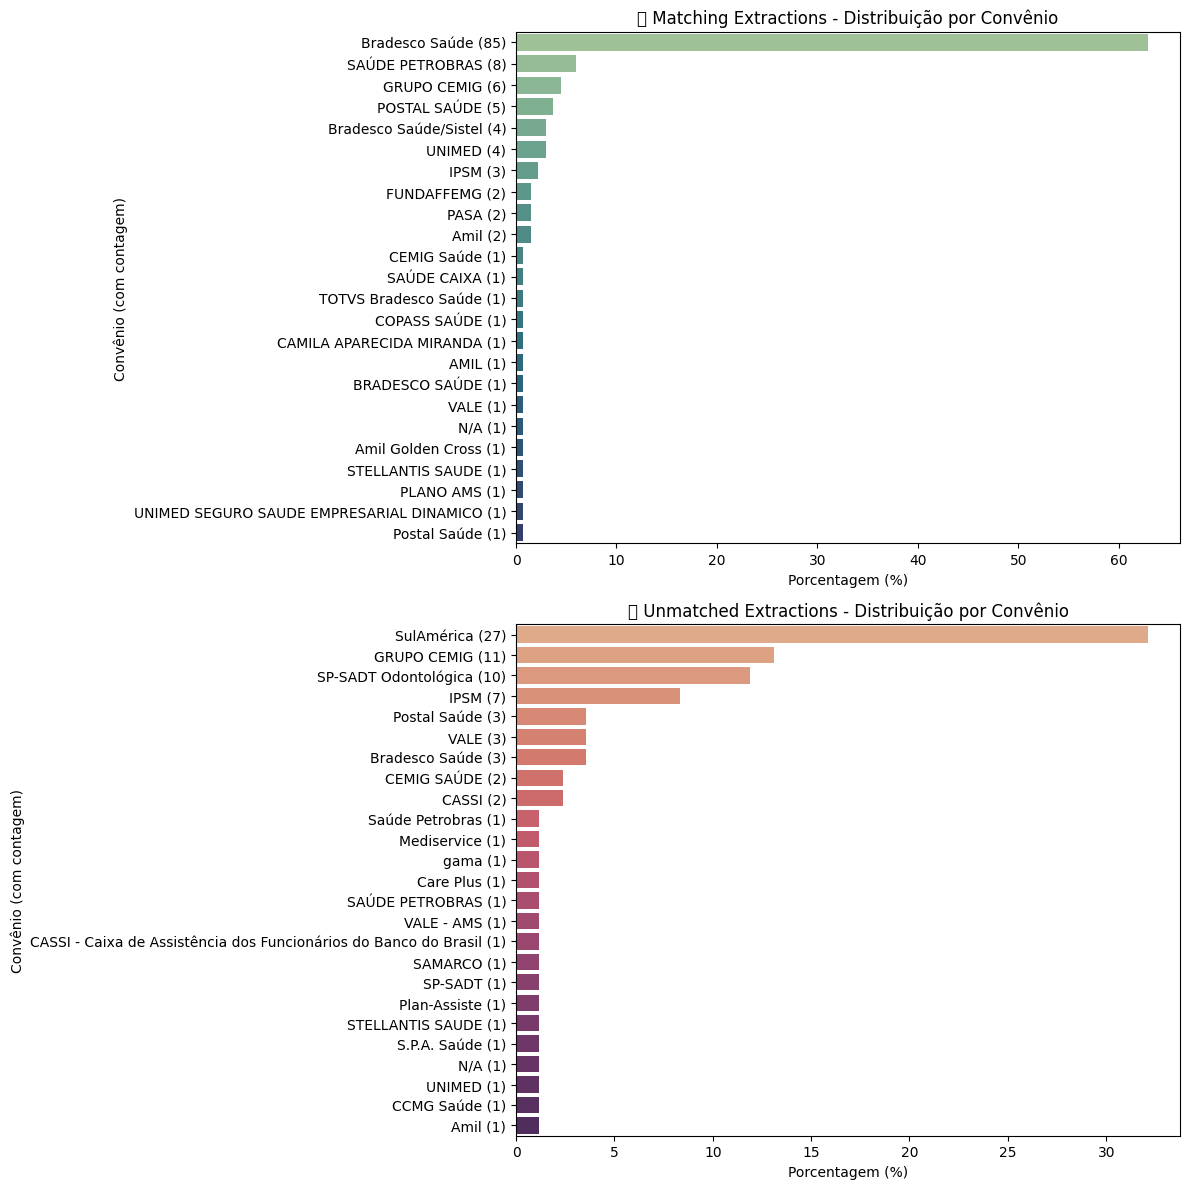

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Add the label column again (if not done already)
df_matching["label"] = df_matching.apply(lambda row: f"{row['convenio']} ({row['count']})", axis=1)
df_unmatched["label"] = df_unmatched.apply(lambda row: f"{row['convenio']} ({row['count']})", axis=1)

# Step 2: Sort bars by percentage descending
df_matching_sorted = df_matching.sort_values(by="percentage", ascending=False)
df_unmatched_sorted = df_unmatched.sort_values(by="percentage", ascending=False)

# Step 3: Create horizontal bar plots
fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)

# 🔹 Matching plot (horizontal)
sns.barplot(
    data=df_matching_sorted,
    y="label",
    x="percentage",
    ax=axes[0],
    palette="crest"
)
axes[0].set_title("✅ Matching Extractions - Distribuição por Convênio")
axes[0].set_xlabel("Porcentagem (%)")
axes[0].set_ylabel("Convênio (com contagem)")

# 🔸 Unmatched plot (horizontal)
sns.barplot(
    data=df_unmatched_sorted,
    y="label",
    x="percentage",
    ax=axes[1],
    palette="flare"
)
axes[1].set_title("❌ Unmatched Extractions - Distribuição por Convênio")
axes[1].set_xlabel("Porcentagem (%)")
axes[1].set_ylabel("Convênio (com contagem)")

plt.tight_layout()
plt.show()



In [131]:
# from strands import Agent

# model_id = multimodal_llms[0][0]  # Use the first model ID for the agent
# # Create an agent with default settings
# agent = Agent(model=model_id)

# # Ask the agent a question
# agent("Tell me about agentic AI")